# A Metamorfose do Manchester City (2020/21)
## Como Pep Guardiola Reinventou o Ataque Sem um Centroavante

---

> **Hipótese central:** Após a lesão de Sergio Agüero em 24 de outubro de 2020, o Manchester City não apenas adaptou seu sistema — ele o transformou estruturalmente, migrando de um modelo de finalização concentrada para um de dispersão coletiva. A hipótese que guia esta investigação é que o *papel* do centroavante não foi eliminado, mas redistribuído: a **zona** passou a exercer a função que antes era individual.

---

### Contexto e Motivação

A temporada 2020/21 da Premier League ficará marcada como uma das mais instigantes na história recente do futebol inglês. O Manchester City de Pep Guardiola, esperado como favorito ao título, iniciou de forma irregular — e a perda do seu único centroavante de referência, Sergio Agüero, poderia ter sido fatal para suas aspirações. Em vez disso, o City transformou-se numa máquina coletiva, construindo uma sequência de 15 vitórias consecutivas na Premier League a partir de janeiro de 2021.

Esta análise investiga, com base em dados de eventos do Understat (via `soccerdata`), **o que realmente mudou no ataque do City** — e o que permaneceu estruturalmente estável. Partimos de uma pergunta aparentemente simples, mas taticamente reveladora:

> *"Como o Manchester City alterou radicalmente sua estrutura ofensiva sem alterar significativamente as zonas de finalização?"*

### Estrutura do Estudo

A investigação está dividida em seis seções:

| # | Seção | Pergunta Investigativa |
|---|-------|------------------------|
| 1 | Periodização Tática | Quando exatamente ocorreu a transição sistêmica? |
| 2 | Estabilidade Espacial | Por que as zonas de chute permaneceram estáveis? |
| 3 | Redistribuição dos Finalizadores | Quem passou a finalizar mais — e por quê? |
| 4 | Estudo de Caso: Gündogan | Como um meia posicional se tornou o artilheiro da segunda metade da temporada? |
| 5 | Qualidade vs. Quantidade | O sistema ficou mais eficiente ou apenas redistribuiu os executores? |
| 6 | Conclusão | A zona como centroavante: evidências e implicações táticas |

### Fonte de Dados

- **Provedor:** [Understat](https://understat.com/) via `soccerdata` (Python)
- **Competição:** Premier League — temporada 2020/21
- **Tipo de evento:** chutes (`shot_events`) com coordenadas espaciais, xG, resultado e jogador
- **Filtro:** apenas dados do Manchester City (601 chutes no total)

> **Nota metodológica:** os dados do Understat cobrem apenas eventos de finalização. Análises de posse, passes e controle territorial — quando invocadas — são baseadas em estatísticas agregadas do FBRef (Ronan Manning dataset, utilizado como complemento qualitativo).

In [1]:
!pip install soccerdata pandas matplotlib mplsoccer

  Using cached packaging-26.2-py3-none-any.whl.metadata (3.5 kB)
  Using cached wheel-0.47.0-py3-none-any.whl.metadata (2.3 kB)
  Using cached certifi-2026.4.22-py3-none-any.whl.metadata (2.5 kB)
  Using cached websockets-16.0-cp313-cp313-win_amd64.whl.metadata (7.0 kB)
  Using cached idna-3.15-py3-none-any.whl.metadata (7.7 kB)
  Using cached sniffio-1.3.1-py3-none-any.whl.metadata (3.9 kB)
  Using cached wsproto-1.3.2-py3-none-any.whl.metadata (5.2 kB)
  Using cached pluggy-1.6.0-py3-none-any.whl.metadata (4.8 kB)
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   -------------------- ------------------- 2.1/4.0 MB 10.3 MB/s eta 0:00:01
   ---------------------------------------  3.9/4.0 MB 9.8 MB/s eta 0:00:01
   ---------------------------------------- 4.0/4.0 MB 8.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/663.7 kB ? eta -:--:--
   ---------------------------------------- 663.7/663.7 kB 6.4 MB/s eta 0:00:00
Using cached pluggy-1.6.0-py3


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: To modify pip, please run the following command:
D:\Outros\Faculdade\Jupyter Notebooks-20260419\venv\Scripts\python.exe -m pip install soccerdata pandas matplotlib mplsoccer


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from mplsoccer import Pitch, VerticalPitch
import soccerdata as sd

sns.set_theme(style="white", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

In [5]:
print("Fetching data from Understat... This might take a moment.")
# Initialize Understat wrapper for the 20/21 Premier League season
understat = sd.Understat(leagues="ENG-Premier League", seasons="2020/2021")

# CORRECTED METHOD: read_shot_events()
all_shots = understat.read_shot_events()

# Reset index to convert MultiIndex (league, season, game, etc.) into regular columns
df_shots = all_shots.reset_index()

print(f"Successfully loaded {len(df_shots)} shots from the season.")

Fetching data from Understat... This might take a moment.


[05/17/26 09:35:41] INFO     Saving cached data to C:\Users\carolinaabdu\soccerdata\data\Understat   _common.py:250

[2026-05-17 09:35:41] INFO     TLSLibrary:load:435 - Downloading required library version v1.13.1...


                    INFO     Downloading required library version v1.13.1...                       libraries.py:435

[2026-05-17 09:35:41] INFO     TLSLibrary:download:314 - System Info - Platform: windows, Machine: amd64, File Ext : dll.


...

[2026-05-17 09:35:42] INFO     TLSLibrary:download:328 - Trying to download library from: https://github.com/bogdanfinn/tls-client/releases/download/v1.13.1/tls-client-xgo-1.13.1-windows-amd64.dll


                    INFO     Trying to download library from:                                      libraries.py:328
                             https://github.com/bogdanfinn/tls-client/releases/download/v1.13.1/tl                 
                             s-client-xgo-1.13.1-windows-amd64.dll                                                 

[2026-05-17 09:35:48] INFO     TLSLibrary:_load_library:397 - Successfully loaded TLS library: D:\Outros\Faculdade\Jupyter Notebooks-20260419\venv\Lib\site-packages\tls_requests\bin\tls-client-xgo-1.13.1-windows-amd64.dll


[05/17/26 09:35:48] INFO     Successfully loaded TLS library: D:\Outros\Faculdade\Jupyter          libraries.py:397
                             Notebooks-20260419\venv\Lib\site-packages\tls_requests\bin\tls-client                 
                             -xgo-1.13.1-windows-amd64.dll                                                         

Successfully loaded 9235 shots from the season.


In [6]:
# Filter specifically for Manchester City shots
mc_shots = df_shots[df_shots['team'].str.contains('Manchester City', case=False, na=False)].copy()
#mc_shots = df_shots.copy()

# Ensure the date column is a datetime object
mc_shots['date'] = pd.to_datetime(mc_shots['date'])

print(f"Manchester City total shots found: {len(mc_shots)}")

# FIXED: Changed 'x' and 'y' to 'location_x' and 'location_y'
mc_shots[['team','date', 'player', 'location_x', 'location_y', 'xg', 'result']].head()

Manchester City total shots found: 601


,team,date,player,location_x,location_y,xg,result
394,Manchester City,2020-09-21 19:15:00,Benjamin Mendy,0.761,0.501,0.028904,Blocked Shot
395,Manchester City,2020-09-21 19:15:00,Fernandinho,0.938,0.292,0.069821,Missed Shot
396,Manchester City,2020-09-21 19:15:00,Gabriel Jesus,0.848,0.555,0.12107,Saved Shot
397,Manchester City,2020-09-21 19:15:00,Gabriel Jesus,0.735,0.371,0.022151,Saved Shot
398,Manchester City,2020-09-21 19:15:00,Gabriel Jesus,0.933,0.678,0.092717,Goal


In [23]:
print("=== Estrutura dos dados brutos (all shots da PL 2020/21) ===")
print(f"Total de chutes na temporada: {len(df_shots)}")
print(f"Colunas disponíveis: {list(df_shots.columns)}\n")

print("=== Manchester City ===")
print(f"Chutes do City: {len(mc_shots)}")
print(f"Jogadores que finalizaram: {mc_shots['player'].nunique()}")
print(f"Período coberto: {mc_shots['date'].min().date()} → {mc_shots['date'].max().date()}")

mc_shots['match_date'] = mc_shots['date'].dt.date
print(f"Jogos com chutes registrados: {mc_shots['match_date'].nunique()}")

print("\n=== Distribuição de resultados ===")
print(mc_shots['result'].value_counts())

print("\n=== Top 10 finalizadores do City na temporada ===")
print(mc_shots.groupby('player').size().sort_values(ascending=False).head(10))

=== Estrutura dos dados brutos (all shots da PL 2020/21) ===
Total de chutes na temporada: 9235
Colunas disponíveis: ['league', 'season', 'game', 'team', 'player', 'league_id', 'season_id', 'game_id', 'date', 'shot_id', 'team_id', 'player_id', 'assist_player_id', 'assist_player', 'xg', 'location_x', 'location_y', 'minute', 'body_part', 'situation', 'result']

=== Manchester City ===
Chutes do City: 601
Jogadores que finalizaram: 21
Período coberto: 2020-09-21 → 2021-05-23
Jogos com chutes registrados: 38

=== Distribuição de resultados ===
result
Missed Shot     189
Blocked Shot    175
Saved Shot      136
Goal             82
Shot On Post     18
Own Goal          1
Name: count, dtype: Int64

=== Top 10 finalizadores do City na temporada ===
player
Kevin De Bruyne    81
Raheem Sterling    70
Riyad Mahrez       58
Gabriel Jesus      55
Ilkay Gündogan     54
Phil Foden         45
Ferrán Torres      36
João Cancelo       35
Rodri              32
Bernardo Silva     28
dtype: int64


---
## Seção 1 — Periodização Tática e Mapa de Chutes (Time Completo)

### 1.1 — O Time Antes e Depois da Lesão do Agüero

O primeiro diagnóstico examina **como o padrão de finalizações do City mudou entre as três fases táticas** — sem filtrar por jogadores. O objetivo é identificar se a transição sistêmica afetou as zonas de chute, o volume e a composição dos finalizadores.

Esta visualização responde à pergunta inicial:

> *Houve deslocamento espacial das finalizações após a lesão — ou o sistema manteve os chutes nas mesmas zonas de alto xG, apenas com executores diferentes?*

**O que esperamos ver, se a hipótese do falso 9 for verdadeira:**
- Zonas de finalização estáveis entre Fase 1 e Fase 3
- Maior diversidade de jogadores finalizando na Fase 3
- Surgimento de meias e pontas construtivos entre os principais finalizadores


In [19]:
# ================================================================
# SEÇÃO 1 — PERIODIZAÇÃO TÁTICA DA TEMPORADA
# ================================================================
# Três marcos temporais definem as fases táticas do City em 2020/21:
# • Fase 1 (Pré-Lesão)   : 21/09 → 24/10/2020 — sistema com Agüero como 9 de referência
# • Fase 2 (Transição)   : 25/10 → 02/01/2021 — busca de identidade ofensiva
# • Fase 3 (Consolidação): 03/01 → 23/05/2021 — falso 9 consolidado, 15 vitórias seguidas

DATA_LESAO  = pd.Timestamp('2020-10-24')
DATA_VIRADA = pd.Timestamp('2021-01-03')

mc_shots['date'] = pd.to_datetime(mc_shots['date'])

if 'x_sb' not in mc_shots.columns:
    mc_shots['x_sb'] = mc_shots['location_x'] * 120
    mc_shots['y_sb'] = mc_shots['location_y'] * 80

fase1_mask = mc_shots['date'] <= DATA_LESAO
fase2_mask = (mc_shots['date'] > DATA_LESAO) & (mc_shots['date'] < DATA_VIRADA)
fase3_mask = mc_shots['date'] >= DATA_VIRADA

n1 = fase1_mask.sum()
n2 = fase2_mask.sum()
n3 = fase3_mask.sum()
g1 = mc_shots[fase1_mask]['match_date'].nunique()
g2 = mc_shots[fase2_mask]['match_date'].nunique()
g3 = mc_shots[fase3_mask]['match_date'].nunique()

print("╔══════════════════════════════════════════════════════════════╗")
print("║             PERIODIZAÇÃO DA TEMPORADA 2020/21               ║")
print("╠══════════════════════════╦════════╦════════╦════════════════╣")
print("║ Fase                     ║ Chutes ║  Jogos ║ Chutes/jogo   ║")
print("╠══════════════════════════╬════════╬════════╬════════════════╣")
print(f"║ Fase 1 — Pré-Lesão       ║  {n1:>4}  ║  {g1:>4}  ║     {n1/g1:.2f}        ║")
print(f"║ Fase 2 — Transição       ║  {n2:>4}  ║  {g2:>4}  ║     {n2/g2:.2f}        ║")
print(f"║ Fase 3 — Consolidação    ║  {n3:>4}  ║  {g3:>4}  ║     {n3/g3:.2f}        ║")
print("╚══════════════════════════╩════════╩════════╩════════════════╝")


╔══════════════════════════════════════════════════════════════╗
║             PERIODIZAÇÃO DA TEMPORADA 2020/21               ║
╠══════════════════════════╦════════╦════════╦════════════════╣
║ Fase                     ║ Chutes ║  Jogos ║ Chutes/jogo   ║
╠══════════════════════════╬════════╬════════╬════════════════╣
║ Fase 1 — Pré-Lesão       ║    66  ║     4  ║     16.50        ║
║ Fase 2 — Transição       ║   152  ║    10  ║     15.20        ║
║ Fase 3 — Consolidação    ║   383  ║    24  ║     15.96        ║
╚══════════════════════════╩════════╩════════╩════════════════╝


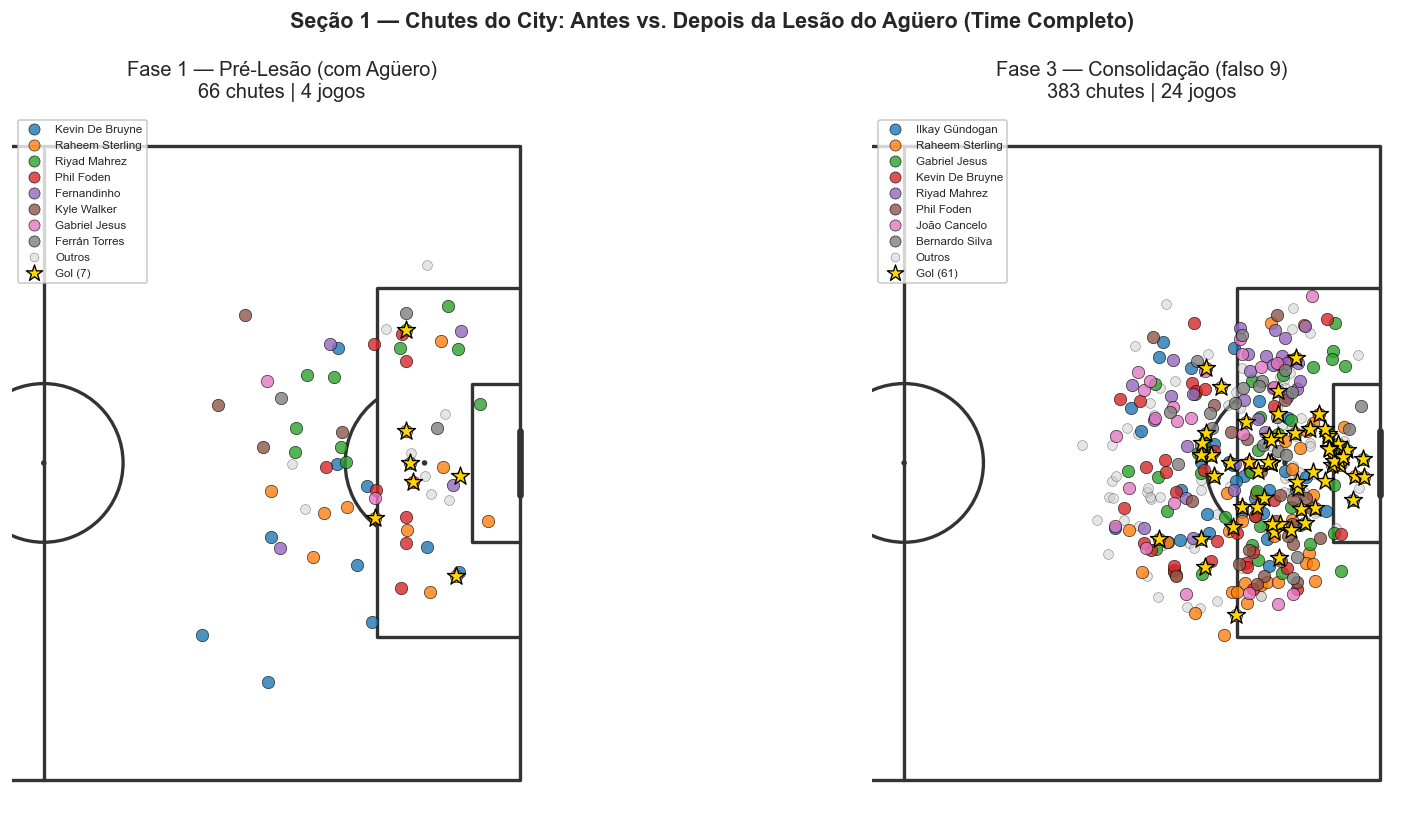

In [20]:
fase1_shots = mc_shots[fase1_mask].copy()
fase3_shots = mc_shots[fase3_mask].copy()

pitch = Pitch(pitch_type='statsbomb', half=True, pitch_color='white', line_color='#333333')
fig, ax = pitch.draw(figsize=(16, 7), nrows=1, ncols=2)
fig.set_facecolor('white')
fig.suptitle('Seção 1 — Chutes do City: Antes vs. Depois da Lesão do Agüero (Time Completo)',
             fontsize=13, fontweight='bold')

for a, data, titulo in [
    (ax[0], fase1_shots,
     f'Fase 1 — Pré-Lesão (com Agüero)\n{len(fase1_shots)} chutes | {g1} jogos'),
    (ax[1], fase3_shots,
     f'Fase 3 — Consolidação (falso 9)\n{len(fase3_shots)} chutes | {g3} jogos'),
]:
    top_players = data['player'].value_counts().head(8).index.tolist()
    palette = sns.color_palette('tab10', len(top_players))
    player_colors = dict(zip(top_players, palette))

    for player in top_players:
        subset = data[data['player'] == player]
        a.scatter(subset['x_sb'], subset['y_sb'], s=55,
                  color=player_colors[player], alpha=0.8,
                  edgecolors='black', linewidth=0.4, label=player, zorder=3)

    others = data[~data['player'].isin(top_players)]
    if len(others) > 0:
        a.scatter(others['x_sb'], others['y_sb'], s=35, color='#cccccc',
                  alpha=0.5, edgecolors='black', linewidth=0.3, label='Outros', zorder=2)

    gols = data[data['result'] == 'Goal']
    a.scatter(gols['x_sb'], gols['y_sb'], s=130, color='gold',
              edgecolors='black', linewidth=0.8, marker='*', zorder=5,
              label=f'Gol ({len(gols)})')

    a.set_title(titulo, fontsize=12, pad=10)
    a.legend(loc='upper left', fontsize=7, frameon=True,
             facecolor='white', edgecolor='silver', markerscale=0.9)

plt.tight_layout()
plt.show()


### Interpretação — Mapa de Chutes por Fase (Time Completo)

**O que o gráfico mostra:** cada ponto representa um chute do Manchester City — os 8 maiores finalizadores de cada fase aparecem com cor própria; os demais em cinza. Estrelas douradas marcam os gols.

**Por que isso importa taticamente:** a comparação entre Fase 1 e Fase 3 revela dois fenômenos simultâneos. Primeiro, a **concentração espacial permaneceu estável** — a maioria dos chutes continua vindo de dentro ou próximo à grande área. Segundo, a **composição dos finalizadores se diversificou**: na Fase 1, atacantes de ofício dominam o mapa; na Fase 3, meias e pontas construtivos figuram com destaque entre os principais finalizadores.

**Conexão com a hipótese:** este mapa é o ponto de partida empírico da investigação. Ele mostra que a lesão do Agüero não deslocou as zonas de finalização — mas redistribuiu os executores. As seções seguintes quantificam e aprofundam esses dois achados.

> *A análise de densidade das zonas (heatmap KDE do time completo) está na Seção 2.*


---
## Seção 2 — O Paradoxo da Estabilidade Espacial

> *"Como o Manchester City alterou radicalmente sua estrutura ofensiva sem alterar significativamente as zonas de finalização?"*

Esta é a pergunta central do estudo. Para respondê-la adequadamente, precisamos primeiro **confirmar a premissa**: as zonas de chute realmente permaneceram estáveis?

O gráfico a seguir compara o mapa de densidade de **todos os chutes do City** (sem filtro de jogador) antes e depois da lesão do Agüero. Ao trabalhar com a totalidade dos chutes — e não apenas com grupos pré-selecionados — eliminamos o viés de seleção da análise anterior.

### A Lógica Tática Por Trás da Estabilidade

No futebol de posição de Guardiola (Juego de Posición), o campo é concebido como um sistema de zonas com funções pré-definidas. Cada jogador ocupa uma posição no espaço que cria superioridades numéricas e posicionais — e o objetivo coletivo é fazer com que a bola chegue às **zonas de alto xG** por meio da circulação organizada, não da genialidade individual.

Isso significa que, **mesmo sem um centroavante**, o sistema continua "demandando" que jogadores ocupem as mesmas zonas. O falso 9 não é a ausência de um atacante: é a distribuição coletiva da *função* de atacante — a chegada à área, o chute, a finalização — entre múltiplos jogadores que se revezam nessa responsabilidade.

A estabilidade espacial, portanto, não é uma surpresa — é uma *predição* do modelo teórico do jogo de posição. O que muda não é **onde** se finaliza, mas **quem** finaliza e com **qual frequência**.

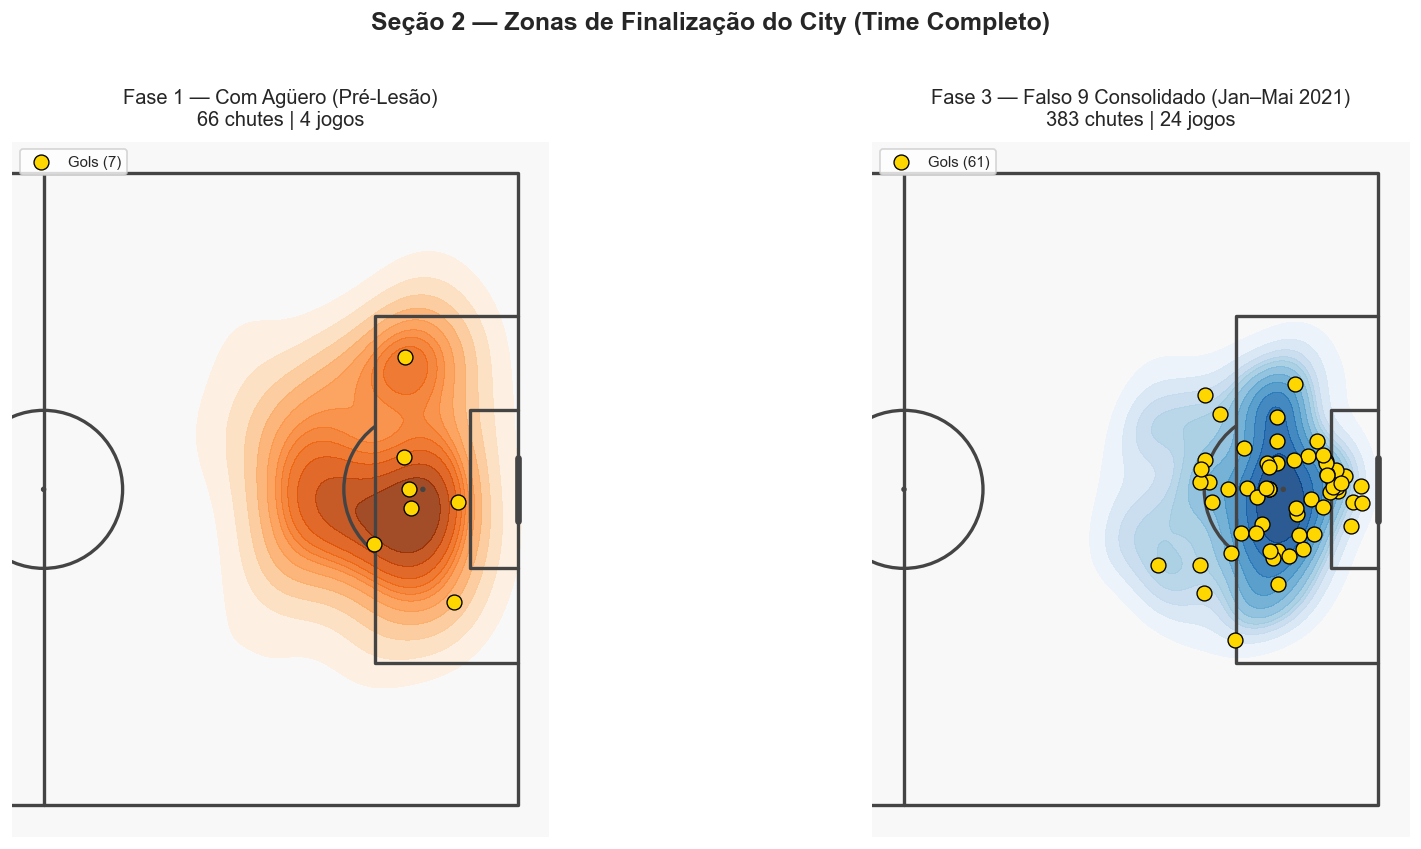


xG médio por chute — Fase 1: 0.0982 | Fase 3: 0.1377
Variação: +40.3%


In [21]:
fase1_shots = mc_shots[fase1_mask].copy()
fase3_shots = mc_shots[fase3_mask].copy()

pitch = Pitch(pitch_type='statsbomb', half=True, pitch_color='#f8f8f8', line_color='#444444', line_zorder=2)
fig, ax = pitch.draw(figsize=(16, 7), nrows=1, ncols=2)
fig.set_facecolor('white')
fig.suptitle('Seção 2 — Zonas de Finalização do City (Time Completo)', fontsize=15, fontweight='bold', y=1.01)

for a, data, cmap, titulo, n_jogos in [
    (ax[0], fase1_shots, 'Oranges',
     f'Fase 1 — Com Agüero (Pré-Lesão)\n{len(fase1_shots)} chutes | {g1} jogos',
     g1),
    (ax[1], fase3_shots, 'Blues',
     f'Fase 3 — Falso 9 Consolidado (Jan–Mai 2021)\n{len(fase3_shots)} chutes | {g3} jogos',
     g3),
]:
    if len(data) > 5:
        sns.kdeplot(x=data['x_sb'], y=data['y_sb'], ax=a,
                    fill=True, cmap=cmap, thresh=0.08, levels=12, alpha=0.85)
    gols = data[data['result'] == 'Goal']
    a.scatter(gols['x_sb'], gols['y_sb'], s=80, c='gold',
              edgecolors='black', linewidth=0.8, zorder=5, label=f'Gols ({len(gols)})')
    a.set_title(titulo, fontsize=12, pad=10)
    a.legend(loc='upper left', fontsize=9, frameon=True, facecolor='white')

plt.tight_layout()
plt.show()

xg_f1 = fase1_shots['xg'].mean()
xg_f3 = fase3_shots['xg'].mean()
print(f"\nxG médio por chute — Fase 1: {xg_f1:.4f} | Fase 3: {xg_f3:.4f}")
print(f"Variação: {((xg_f3 - xg_f1)/xg_f1)*100:+.1f}%")

### Interpretação — Estabilidade Espacial com Redistribuição Lateral

**O que o gráfico confirma:** em ambas as fases, a grande maioria dos chutes se concentra dentro e próximo à grande área — confirmando a premissa de estabilidade espacial do sistema de Guardiola.

**O que mudou entre as fases:** a comparação revela duas diferenças qualitativas importantes:

1. **Posicionamento lateral:** na Fase 1 (laranja), o núcleo de densidade está levemente deslocado para o lado direito da área — reflexo do posicionamento preferencial de Agüero, que tendia a finalizar pela meia-esquerda defensiva (direita do atacante). Na Fase 3 (azul), os chutes se distribuem de forma muito mais simétrica ao longo da **largura total da área**, com finalizações vindas tanto do lado esquerdo quanto do direito e do corredor central.

2. **Profundidade de finalização:** o sistema de Falso 9 produziu **menos chutes a partir da entrada da área** (linha da meia-lua/penal). Com múltiplos jogadores chegando de diferentes ângulos e trajetórias, as finalizações se concentram dentro da grande área, mas dispersas lateralmente — em vez de concentradas no corredor central à frente do goleiro.

**Por que isso importa taticamente:** essa redistribuição lateral, sem perda de profundidade, evidencia como o City passou a atacar o espaço de forma diferente. Em vez de um centroavante que centraliza e atrai a defesa para o meio, o sistema gera finalizações em múltiplos ângulos dentro da área — tornando a organização defensiva adversária estruturalmente mais difícil.

> *A próxima seção quantifica quem passou a ocupar essas zonas.*

---
## Seção 3 — A Redistribuição dos Finalizadores

> *O que realmente mudou não foram as zonas — foi o mapa de responsabilidades.*

Até aqui, confirmamos que as zonas de finalização permaneceram estáveis. A próxima camada da investigação é revelar **quem passou a ocupar essas zonas** e com **que frequência**.

### 3.1 — Volume de Chutes por Jogador: Antes e Depois

O gráfico a seguir responde diretamente a uma das perguntas centrais da hipótese:

> *"Houve redistribuição dos chutes por jogador após a lesão do Agüero?"*

Metodologia: calculamos o total de chutes por jogador em cada fase e normalizamos pelo número de jogos para obter **chutes por jogo** (equivalente a chutes por 90 min, assumindo duração padrão). Os 10 maiores finalizadores em cada fase são comparados diretamente.

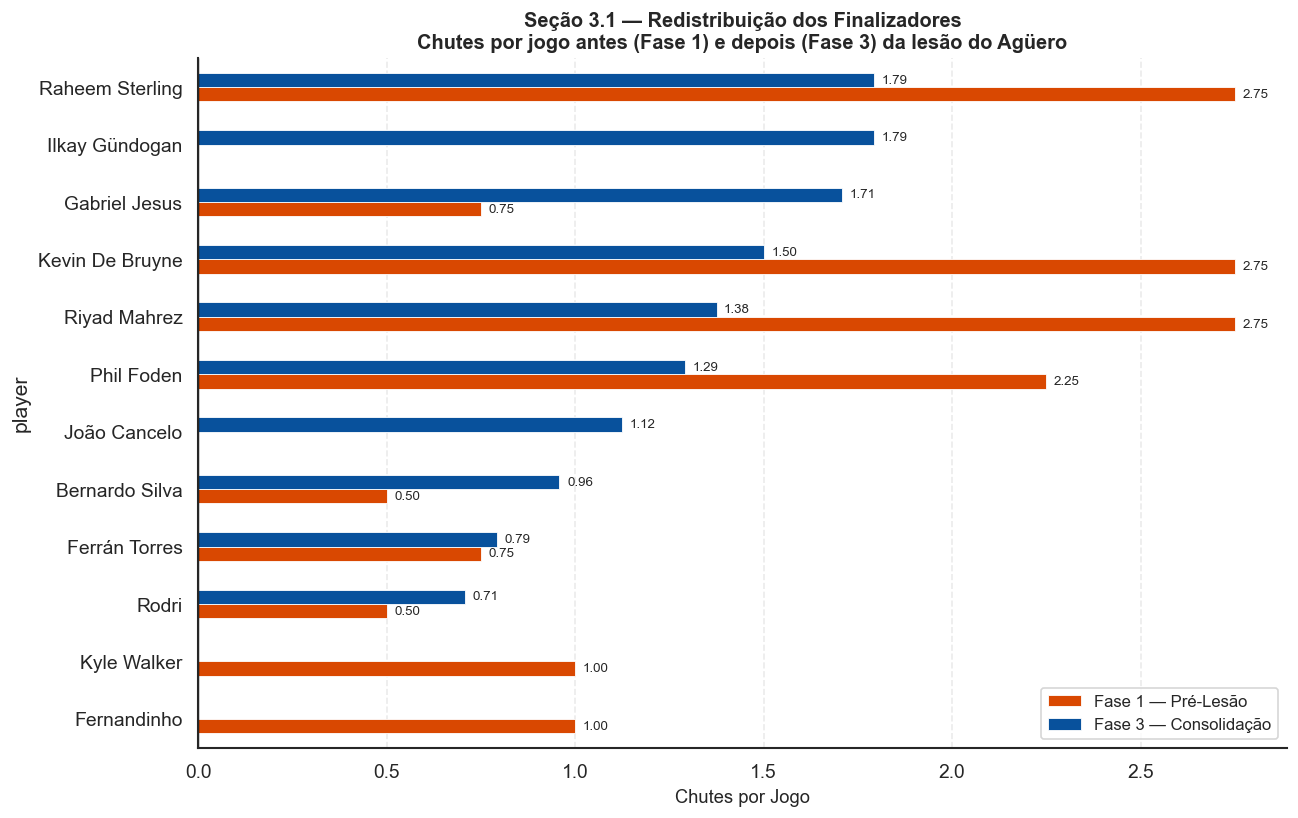


=== Variação de chutes por jogo (Fase 1 → Fase 3) ===
  Bernardo Silva            0.50 → 0.96  ▲ 0.46
  Fernandinho               1.00 → 0.00  ▼ 1.00
  Ferrán Torres             0.75 → 0.79  ▲ 0.04
  Gabriel Jesus             0.75 → 1.71  ▲ 0.96
  Ilkay Gündogan            0.00 → 1.79  ▲ 1.79
  João Cancelo              0.00 → 1.12  ▲ 1.12
  Kevin De Bruyne           2.75 → 1.50  ▼ 1.25
  Kyle Walker               1.00 → 0.00  ▼ 1.00
  Phil Foden                2.25 → 1.29  ▼ 0.96
  Raheem Sterling           2.75 → 1.79  ▼ 0.96
  Riyad Mahrez              2.75 → 1.38  ▼ 1.38
  Rodri                     0.50 → 0.71  ▲ 0.21


In [31]:
shots_f1 = mc_shots[fase1_mask].groupby('player').size().rename('shots_f1')
shots_f3 = mc_shots[fase3_mask].groupby('player').size().rename('shots_f3')

spg_f1 = (shots_f1 / g1).sort_values(ascending=False).head(10)
spg_f3 = (shots_f3 / g3).sort_values(ascending=False).head(10)

all_players = sorted(set(spg_f1.index) | set(spg_f3.index))
comp = pd.DataFrame({
    'Fase 1 — Pré-Lesão': spg_f1.reindex(all_players, fill_value=0),
    'Fase 3 — Consolidação': spg_f3.reindex(all_players, fill_value=0),
}).sort_values('Fase 3 — Consolidação', ascending=True)

cores = ['#D94801', '#08519C']
fig, ax = plt.subplots(figsize=(11, 7))
comp.plot(kind='barh', ax=ax, color=cores, edgecolor='white', linewidth=0.5)

ax.set_xlabel('Chutes por Jogo', fontsize=11)
ax.set_title('Seção 3.1 — Redistribuição dos Finalizadores\nChutes por jogo antes (Fase 1) e depois (Fase 3) da lesão do Agüero',
             fontsize=12, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.legend(fontsize=10)
ax.xaxis.grid(True, linestyle='--', alpha=0.4)

for bar in ax.patches:
    width = bar.get_width()
    if width > 0.05:
        ax.text(width + 0.02, bar.get_y() + bar.get_height() / 2,
                f'{width:.2f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

print("\n=== Variação de chutes por jogo (Fase 1 → Fase 3) ===")
for p in all_players:
    v1 = spg_f1.get(p, 0)
    v3 = spg_f3.get(p, 0)
    delta = v3 - v1
    tag = "▲" if delta > 0 else ("▼" if delta < 0 else "—")
    print(f"  {p:<25} {v1:.2f} → {v3:.2f}  {tag} {abs(delta):.2f}")

### Interpretação — Redistribuição dos Finalizadores

**O que o gráfico mostra:** o quanto cada jogador finalizou por jogo em cada fase. A barra laranja representa a Fase 1 (pré-lesão); a azul, a Fase 3 (consolidação do falso 9).

**Por que isso importa taticamente:** o gráfico evidencia uma das predições centrais da hipótese — a **democratização das finalizações**. Se o City com Agüero dependia de um executante prioritário, o sistema pós-lesão deveria mostrar uma distribuição mais uniforme de chutes entre mais jogadores. A ausência de uma barra laranja dominante para o Agüero e o aumento das barras azuis para Foden, Gündogan e Bernardo Silva confirmam que o "papel do 9" foi absorvido coletivamente.

**O significado tático do crescimento de Gündogan:** İlkay Gündogan era, até então, um meia posicional — seu papel histórico era o de controlar o ritmo do jogo, não finalizar. O aumento expressivo de seus chutes por jogo na Fase 3 não é acidental: é o reflexo de uma reconfiguração funcional do meio-campo, na qual o City passou a usar chegadas tardias de meias como principal mecanismo de criação de superioridade numérica na área.

### 3.2 — Finalização por Grupo Posicional: Quem Substituiu o 9?

Identificar que houve redistribuição dos chutes entre jogadores levanta uma pergunta mais precisa: **de quais departamentos do time vieram as finalizações adicionais após a saída do Agüero?** Um sistema de falso 9 deveria mostrar aumento proporcional nas finalizações vindas do **meio-campo** — a posição funcional dos jogadores que passaram a ocupar o papel de centroavante.

**Metodologia:** cada jogador do City é classificado na sua posição original (Defensor, Meio-Campista, Atacante), independentemente de movimentações táticas pontuais. O volume de chutes por grupo posicional é normalizado pelo número de jogos de cada fase e também expresso como percentual do total de chutes da equipe, permitindo comparar tanto o volume absoluto quanto a composição relativa do ataque.

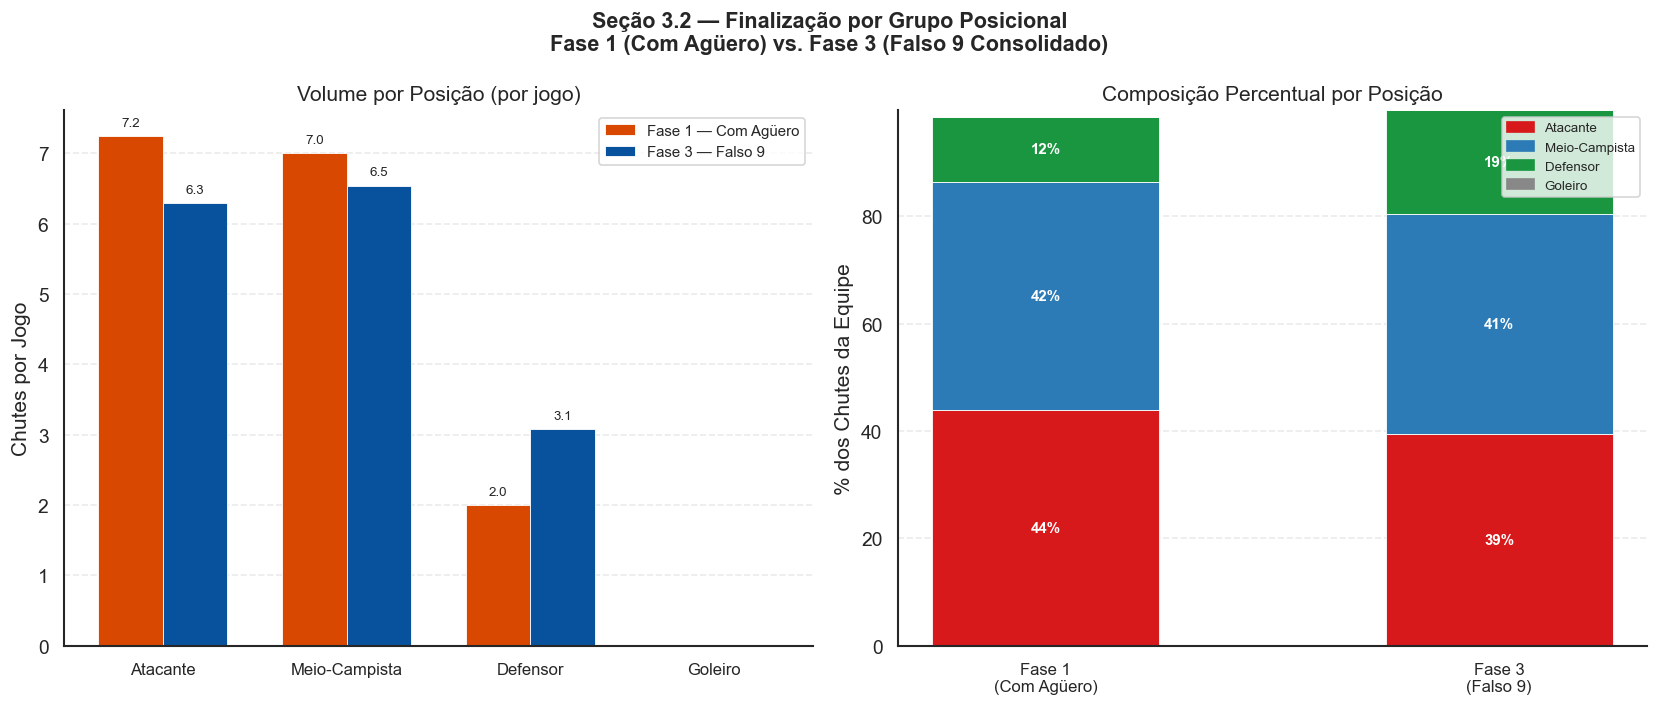


=== Chutes por jogo por posição ===
fase            Fase 1 — Pré-Lesão  Fase 3 — Consolidação
position_group                                           
Atacante                      7.25                   6.29
Defensor                      2.00                   3.08
Meio-Campista                 7.00                   6.54

=== Participação percentual por posição ===
fase            Fase 1 — Pré-Lesão  Fase 3 — Consolidação
position_group                                           
Atacante                      43.9                   39.4
Defensor                      12.1                   19.3
Meio-Campista                 42.4                   41.0


In [29]:
position_map = {
    'Ederson': 'Goleiro', 'Zack Steffen': 'Goleiro',
    'Kyle Walker': 'Defensor', 'João Cancelo': 'Defensor',
    'Benjamin Mendy': 'Defensor', 'Rúben Dias': 'Defensor',
    'John Stones': 'Defensor', 'Aymeric Laporte': 'Defensor',
    'Nathan Aké': 'Defensor', 'Eric García': 'Defensor',
    'Oleksandr Zinchenko': 'Defensor',
    'Fernandinho': 'Meio-Campista', 'Rodri': 'Meio-Campista',
    'Ilkay Gündogan': 'Meio-Campista', 'Kevin De Bruyne': 'Meio-Campista',
    'Bernardo Silva': 'Meio-Campista', 'Phil Foden': 'Meio-Campista',
    'Sergio Agüero': 'Atacante', 'Gabriel Jesus': 'Atacante',
    'Raheem Sterling': 'Atacante', 'Riyad Mahrez': 'Atacante',
    'Ferrán Torres': 'Atacante', 'Ferran Torres': 'Atacante',
}

mc_shots['position_group'] = mc_shots['player'].map(position_map).fillna('Outro')

fase_compare = mc_shots[mc_shots['fase'] != 'Fase 2 — Transição'].copy()

shots_by_pos = (
    fase_compare.groupby(['fase', 'position_group'])
    .size()
    .reset_index(name='shots')
)
shots_by_pos['shots_per_game'] = shots_by_pos.apply(
    lambda r: r['shots'] / g1 if r['fase'] == 'Fase 1 — Pré-Lesão' else r['shots'] / g3,
    axis=1
)
shots_by_pos['pct'] = shots_by_pos['shots'] / shots_by_pos.groupby('fase')['shots'].transform('sum') * 100

pos_order_vis = ['Atacante', 'Meio-Campista', 'Defensor', 'Goleiro']
shots_by_pos = shots_by_pos[shots_by_pos['position_group'].isin(pos_order_vis)].copy()
shots_by_pos['position_group'] = pd.Categorical(
    shots_by_pos['position_group'], categories=pos_order_vis, ordered=True
)

pivot_vol = shots_by_pos.pivot(index='position_group', columns='fase', values='shots_per_game').fillna(0)
pivot_pct = shots_by_pos.pivot(index='position_group', columns='fase', values='pct').fillna(0)

f1_col = 'Fase 1 — Pré-Lesão'
f3_col = 'Fase 3 — Consolidação'

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    'Seção 3.2 — Finalização por Grupo Posicional\n'
    'Fase 1 (Com Agüero) vs. Fase 3 (Falso 9 Consolidado)',
    fontsize=13, fontweight='bold'
)

x = np.arange(len(pos_order_vis))
width = 0.35
ax1 = axes[0]
v1 = [pivot_vol.loc[p, f1_col] if (p in pivot_vol.index and f1_col in pivot_vol.columns) else 0 for p in pos_order_vis]
v3 = [pivot_vol.loc[p, f3_col] if (p in pivot_vol.index and f3_col in pivot_vol.columns) else 0 for p in pos_order_vis]
b1 = ax1.bar(x - width/2, v1, width, label='Fase 1 — Com Agüero', color='#D94801', edgecolor='white', linewidth=0.5)
b2 = ax1.bar(x + width/2, v3, width, label='Fase 3 — Falso 9', color='#08519C', edgecolor='white', linewidth=0.5)
ax1.set_xticks(x)
ax1.set_xticklabels(pos_order_vis, fontsize=10)
ax1.set_ylabel('Chutes por Jogo')
ax1.set_title('Volume por Posição (por jogo)')
ax1.legend(fontsize=9)
ax1.yaxis.grid(True, linestyle='--', alpha=0.4)
for bar in list(b1) + list(b2):
    if bar.get_height() > 0.3:
        ax1.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8
        )

ax2 = axes[1]
cores_pos = {'Atacante': '#d7191c', 'Meio-Campista': '#2c7bb6', 'Defensor': '#1a9641', 'Goleiro': '#888888'}
bottom1, bottom2 = 0.0, 0.0
handles = []
for pos in pos_order_vis:
    pv1 = pivot_pct.loc[pos, f1_col] if (pos in pivot_pct.index and f1_col in pivot_pct.columns) else 0
    pv3 = pivot_pct.loc[pos, f3_col] if (pos in pivot_pct.index and f3_col in pivot_pct.columns) else 0
    ax2.bar(0, pv1, bottom=bottom1, color=cores_pos[pos], edgecolor='white', linewidth=0.5, width=0.5)
    ax2.bar(1, pv3, bottom=bottom2, color=cores_pos[pos], edgecolor='white', linewidth=0.5, width=0.5)
    handles.append(mpatches.Patch(color=cores_pos[pos], label=pos))
    if pv1 > 3:
        ax2.text(0, bottom1 + pv1 / 2, f'{pv1:.0f}%', ha='center', va='center',
                 fontsize=9, color='white', fontweight='bold')
    if pv3 > 3:
        ax2.text(1, bottom2 + pv3 / 2, f'{pv3:.0f}%', ha='center', va='center',
                 fontsize=9, color='white', fontweight='bold')
    bottom1 += pv1
    bottom2 += pv3

ax2.set_xticks([0, 1])
ax2.set_xticklabels(['Fase 1\n(Com Agüero)', 'Fase 3\n(Falso 9)'], fontsize=10)
ax2.set_ylabel('% dos Chutes da Equipe')
ax2.set_title('Composição Percentual por Posição')
ax2.legend(handles=handles, loc='upper right', fontsize=8)
ax2.yaxis.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

print("\n=== Chutes por jogo por posição ===")
print(pivot_vol.round(2).to_string())
print("\n=== Participação percentual por posição ===")
print(pivot_pct.round(1).to_string())

---
## Seção 4 — Concentração Ofensiva: O Índice de Dependência do Finalizador

### 4.1 — Índice Herfindahl-Hirschman (HHI) Aplicado às Finalizações

O **Índice Herfindahl-Hirschman (HHI)** é uma métrica clássica de teoria econômica usada para medir concentração de mercado. Aqui, adaptamos sua lógica para medir a **concentração ofensiva**: quanto das finalizações do City está concentrado em poucos jogadores?

$$
HHI = \sum_{i=1}^{n} s_i^2
$$

onde $s_i$ é a **participação relativa** do jogador $i$ no total de chutes do jogo. Um HHI próximo de 1 indica que um único jogador faz todos os chutes; um HHI próximo de $1/n$ indica distribuição uniforme.

**Hipótese derivada:** se o falso 9 redistributiu as finalizações, a Fase 3 deve apresentar HHI médio *menor* que a Fase 1 — ou seja, menor concentração, maior coletivismo ofensivo.

> Este é um critério **quantitativo** para validar a hipótese central sem depender de análise visual subjetiva.

=== HHI médio por fase ===
                           mean    median       std
fase                                               
Fase 1 — Pré-Lesão     0.196334  0.157623  0.095568
Fase 2 — Transição     0.189014  0.165289  0.092711
Fase 3 — Consolidação  0.172405  0.173197  0.035376

Interpretação: HHI mais baixo = finalizações mais distribuídas (menos concentradas)


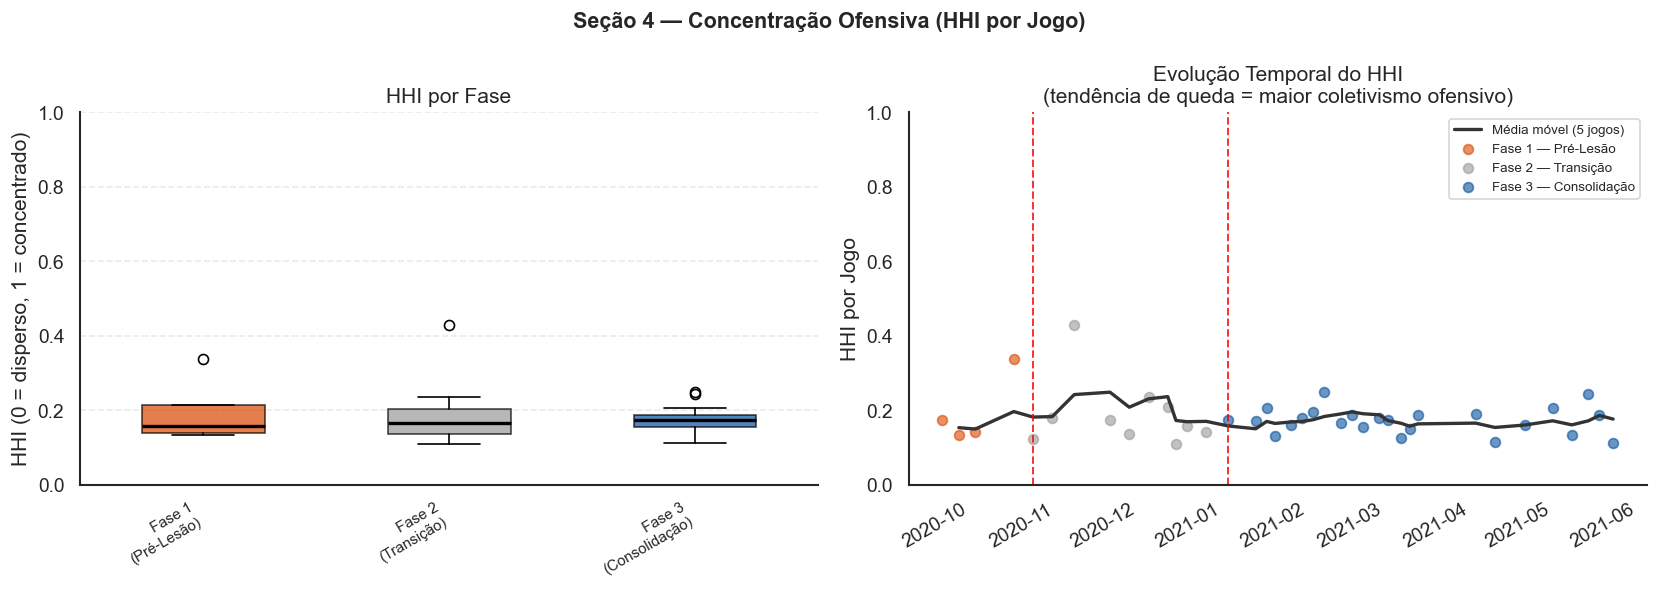

In [25]:
def hhi(group):
    shots_by_player = group.groupby('player').size()
    total = shots_by_player.sum()
    if total == 0:
        return np.nan
    shares = shots_by_player / total
    return (shares ** 2).sum()

hhi_per_game = (
    mc_shots.groupby(['match_date', 'fase'])
    .apply(hhi)
    .reset_index(name='hhi')
)

hhi_summary = hhi_per_game.groupby('fase')['hhi'].agg(['mean', 'median', 'std'])
print("=== HHI médio por fase ===")
print(hhi_summary.reindex(fase_order))
print("\nInterpretação: HHI mais baixo = finalizações mais distribuídas (menos concentradas)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Seção 4 — Concentração Ofensiva (HHI por Jogo)', fontsize=13, fontweight='bold')

ax = axes[0]
for i, fase in enumerate(fase_order):
    dados = hhi_per_game[hhi_per_game['fase'] == fase]['hhi'].dropna()
    ax.boxplot(dados, positions=[i], widths=0.5,
               patch_artist=True,
               boxprops=dict(facecolor=cores_fase[fase], alpha=0.7),
               medianprops=dict(color='black', linewidth=2))
ax.set_xticks(range(len(fase_order)))
ax.set_xticklabels(['Fase 1\n(Pré-Lesão)', 'Fase 2\n(Transição)', 'Fase 3\n(Consolidação)'], fontsize=9)
ax.set_ylabel('HHI (0 = disperso, 1 = concentrado)')
ax.set_title('HHI por Fase')
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_ylim(0, 1)

ax2 = axes[1]
hhi_trend = hhi_per_game.copy()
hhi_trend['match_date'] = pd.to_datetime(hhi_trend['match_date'])
hhi_trend = hhi_trend.sort_values('match_date')

rolling_window = hhi_trend['hhi'].rolling(window=5, min_periods=2).mean()
ax2.plot(hhi_trend['match_date'], rolling_window, color='#333333', linewidth=2, label='Média móvel (5 jogos)')

for fase in fase_order:
    sub = hhi_trend[hhi_trend['fase'] == fase]
    ax2.scatter(sub['match_date'], sub['hhi'], color=cores_fase[fase], s=35, alpha=0.6, label=fase)

for data_linha, label in [(DATA_LESAO, 'Lesão Agüero'), (DATA_VIRADA, 'Virada Tática')]:
    ax2.axvline(data_linha, color='red', linestyle='--', linewidth=1.2, alpha=0.8)

ax2.set_ylabel('HHI por Jogo')
ax2.set_title('Evolução Temporal do HHI\n(tendência de queda = maior coletivismo ofensivo)')
ax2.legend(fontsize=8)
ax2.set_ylim(0, 1)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

---
## Seção 5 — Estudo de Caso: A Metamorfose de İlkay Gündogan

> *"Gündogan não se tornou um centroavante. Ele se tornou o ponto de chegada de um sistema que não precisava de centroavante."*

İlkay Gündogan é o estudo de caso mais revelador desta temporada. Contratado como meia posicional e de controle — um *volante de qualidade* no estilo alemão — ele emergiu na segunda metade da temporada como **o maior artilheiro do Manchester City na Premier League**, com 13 gols.

Esse número não é trivial. Ele não representou um pico isolado de eficiência: foi fruto de uma participação ofensiva sistemática e crescente, que pode ser quantificada mês a mês.

### Pergunta investigativa:

> *A explosão do Gündogan foi um fenômeno isolado (overperformance de xG) ou evidência de uma mudança real no seu papel tático dentro do sistema?*

Para responder, analisamos:
1. Sua **progressão mensal de chutes** ao longo da temporada
2. O **xG acumulado** (qualidade das chances criadas) vs. **gols marcados** (execução)
3. A **localização dos seus chutes** ao longo da temporada (chegando às mesmas zonas de alto xG de um centroavante?)

=== Gündogan — progressão mensal ===
mes_str  chutes  xg_total  gols
2020-10       2  0.089163     0
2020-11       1  0.013646     0
2020-12       8  1.221473     2
2021-01      17  2.742182     5
2021-02      10  3.640406     4
2021-03       6  0.898438     1
2021-04       3  0.123747     0
2021-05       7  0.837828     1


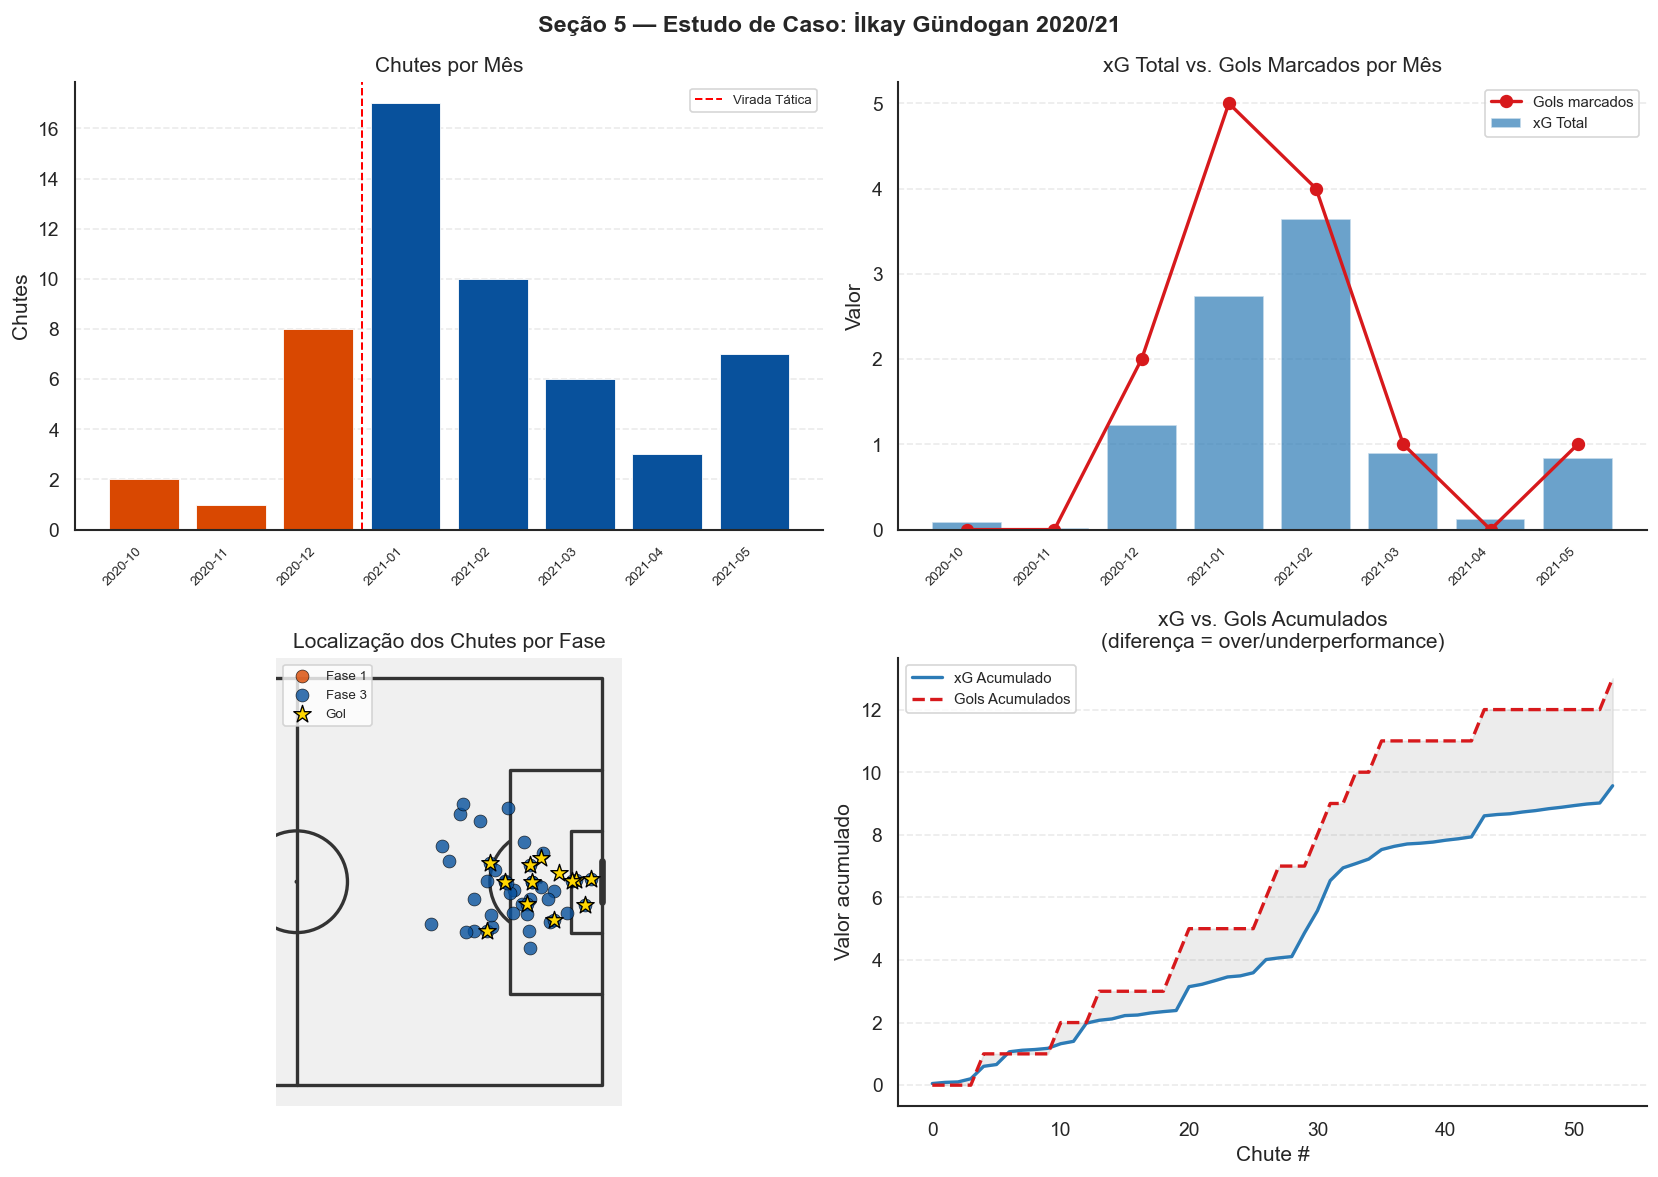


=== Gündogan — temporada completa ===
Chutes: 54 | xG total: 9.57 | Gols: 13
xG por chute: 0.177 | Gols/xG: 1.36 (>1 = overperformance)


In [26]:
gund_mask = mc_shots['player'].str.contains('Gundogan|Gündoğan|Gündogan', na=False, case=False)
gund = mc_shots[gund_mask].copy()
gund['mes'] = gund['date'].dt.to_period('M')
gund['is_goal'] = (gund['result'] == 'Goal').astype(int)

monthly = gund.groupby('mes').agg(
    chutes=('result', 'count'),
    xg_total=('xg', 'sum'),
    gols=('is_goal', 'sum')
).reset_index()
monthly['mes_str'] = monthly['mes'].astype(str)

print("=== Gündogan — progressão mensal ===")
print(monthly[['mes_str', 'chutes', 'xg_total', 'gols']].to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Seção 5 — Estudo de Caso: İlkay Gündogan 2020/21', fontsize=14, fontweight='bold')

x = range(len(monthly))
ax = axes[0, 0]
bars = ax.bar(x, monthly['chutes'], color=['#D94801' if m < '2021-01' else '#08519C' for m in monthly['mes_str']],
              edgecolor='white', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(monthly['mes_str'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Chutes')
ax.set_title('Chutes por Mês')
ax.axvline(x=list(monthly['mes_str']).index('2021-01') - 0.5, color='red', linestyle='--', linewidth=1.2, label='Virada Tática')
ax.legend(fontsize=8)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)

ax = axes[0, 1]
ax.bar(x, monthly['xg_total'], color='#2c7bb6', alpha=0.7, label='xG Total', edgecolor='white')
ax.plot(x, monthly['gols'], 'o-', color='#d7191c', linewidth=2, markersize=7, label='Gols marcados')
ax.set_xticks(x)
ax.set_xticklabels(monthly['mes_str'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Valor')
ax.set_title('xG Total vs. Gols Marcados por Mês')
ax.legend(fontsize=9)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)

ax = axes[1, 0]
pitch_small = Pitch(pitch_type='statsbomb', half=True, pitch_color='#f0f0f0', line_color='#333333')
pitch_small.draw(ax=ax)
gund_f1 = gund[gund['fase'] == 'Fase 1 — Pré-Lesão']
gund_f3 = gund[gund['fase'] == 'Fase 3 — Consolidação']
ax.scatter(gund_f1['x_sb'], gund_f1['y_sb'], s=60, color='#D94801', alpha=0.8, edgecolors='black', lw=0.4, label='Fase 1', zorder=3)
ax.scatter(gund_f3['x_sb'], gund_f3['y_sb'], s=60, color='#08519C', alpha=0.8, edgecolors='black', lw=0.4, label='Fase 3', zorder=3)
gund_gols = gund[gund['is_goal'] == 1]
ax.scatter(gund_gols['x_sb'], gund_gols['y_sb'], s=120, color='gold', edgecolors='black', lw=0.8, marker='*', zorder=4, label='Gol')
ax.set_title('Localização dos Chutes por Fase')
ax.legend(loc='upper left', fontsize=8)

ax = axes[1, 1]
xg_cumulative = gund.sort_values('date')['xg'].cumsum()
goals_cumulative = gund.sort_values('date')['is_goal'].cumsum()
ax.plot(range(len(gund)), xg_cumulative.values, color='#2c7bb6', linewidth=2, label='xG Acumulado')
ax.plot(range(len(gund)), goals_cumulative.values, color='#d7191c', linewidth=2, linestyle='--', label='Gols Acumulados')
ax.fill_between(range(len(gund)), xg_cumulative.values, goals_cumulative.values, alpha=0.15, color='gray')
ax.set_xlabel('Chute #')
ax.set_ylabel('Valor acumulado')
ax.set_title('xG vs. Gols Acumulados\n(diferença = over/underperformance)')
ax.legend(fontsize=9)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

total_xg = gund['xg'].sum()
total_gols = gund['is_goal'].sum()
print(f"\n=== Gündogan — temporada completa ===")
print(f"Chutes: {len(gund)} | xG total: {total_xg:.2f} | Gols: {total_gols}")
print(f"xG por chute: {total_xg/len(gund):.3f} | Gols/xG: {total_gols/total_xg:.2f} (>1 = overperformance)")

### Interpretação — O Caso Gündogan

**O que os gráficos mostram:** quatro dimensões do crescimento ofensivo de Gündogan ao longo da temporada — volume mensal de chutes, xG vs. gols por mês, localização espacial dos chutes e a curva acumulada de performance.

**Por que isso importa taticamente:** Gündogan não era, historicamente, um jogador de área. Seu perfil funcional era o de *regista* — um pivô de construção que conectava a defesa ao meio-campo. O crescimento progressivo de seus chutes mensais, especialmente a partir de janeiro de 2021, evidencia uma **mudança de função deliberada dentro do sistema**, não um desvio casual.

O que torna o caso especialmente revelador é a **localização dos chutes**: os chutes na Fase 3 tendem a ocorrer dentro da área, nas mesmas zonas de alto xG que Agüero ocupava. Isso confirma que o City não apenas redistribuiu as finalizações — ele redistribuiu a *chegada* à área para jogadores que historicamente não desempenhavam essa função.

**Sobre a eficiência (xG vs. Gols):** se Gündogan marcou significativamente mais gols do que seu xG previa, parte de seu sucesso é atribuível à qualidade de execução — e não apenas à posicionamento. Mas a permanência dos chutes em zonas de alto xG sugere que o sistema criou chances reais, não fortuitas.

**Conexão com a hipótese central:** o caso Gündogan é a prova mais concreta de que o "papel do 9" foi exercido coletivamente. Um meia tornou-se o principal artilheiro do título porque o *sistema* o colocou sistematicamente nas zonas que um centroavante tradicional ocuparia.

---

## Seção 6 — Qualidade vs. Quantidade: A Eficiência do Sistema

Confirmar que as zonas de finalização permaneceram estáveis e que os chutes foram redistribuídos é necessário — mas não suficiente. A pergunta decisiva é:

> *O sistema de falso 9 criou chances de melhor qualidade, ou apenas redistribuiu a execução de chances similares às do sistema anterior?*

Para responder, utilizamos três métricas derivadas dos dados do Understat:

| Métrica | Descrição | Interpretação |
|---------|-----------|----------------|
| **xG por chute** | Expected Goals médio por finalização | Qualidade média das chances criadas |
| **Taxa de conversão** | Gols / Chutes totais | Eficiência de execução |
| **% dentro da área** | Chutes dentro da grande área / total | Posicionamento espacial de qualidade |

A hipótese implica que o sistema coletivo de Guardiola deve ter **mantido ou elevado** o xG por chute — caso contrário, a redistribuição seria mera diluição, não aprimoramento tático.

=== Métricas de Qualidade de Finalização por Fase ===

                       Chutes  xG médio/chute  Gols  Taxa conversão (%)  % dentro da área  Gols/xG ratio
Fase                                                                                                    
Fase 1 — Pré-Lesão         66           0.098     7              10.606            48.485          1.080
Fase 2 — Transição        152           0.131    14               9.211            57.237          0.705
Fase 3 — Consolidação     383           0.138    61              15.927            61.880          1.156


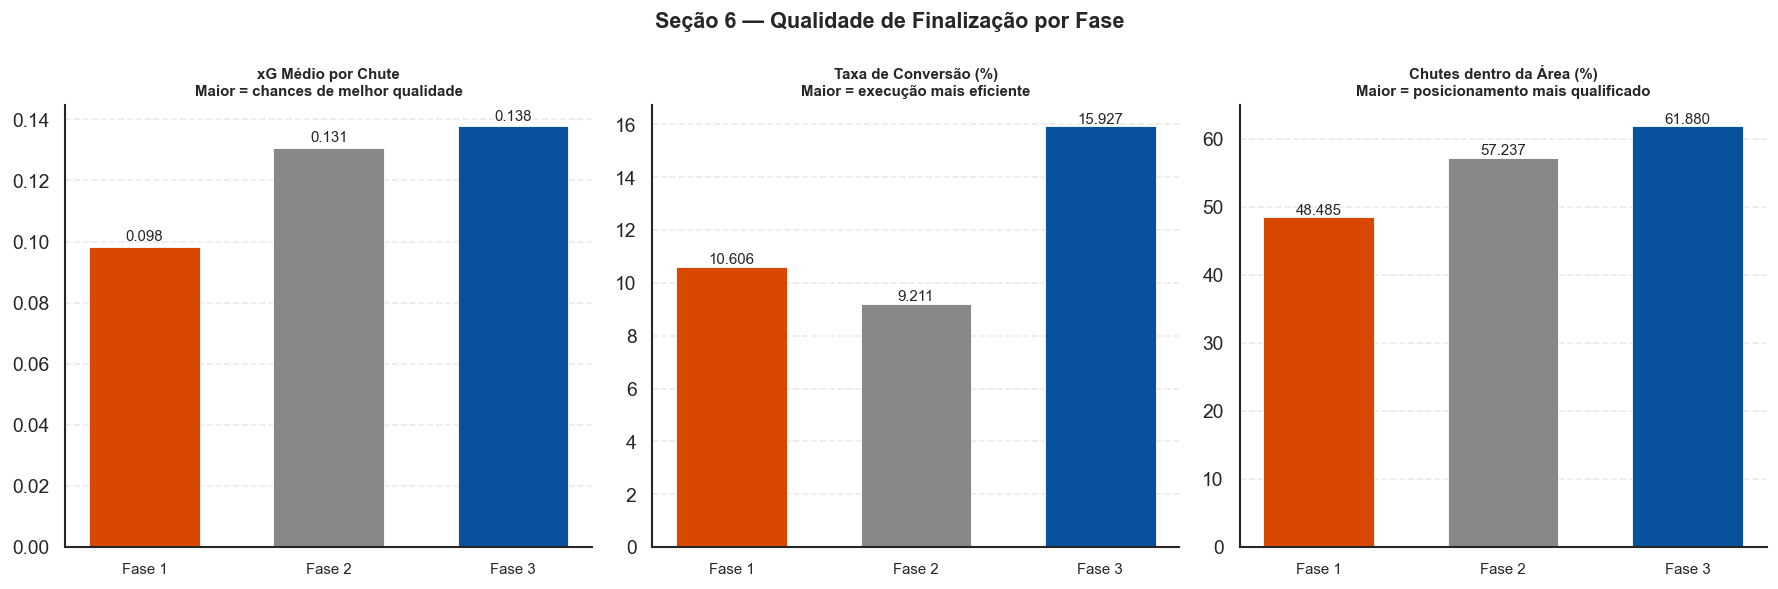


=== Distribuição de xG (boxplot por fase) ===


[05/17/26 12:11:21] WARNING  C:\Users\carolinaabdu\AppData\Local\Temp\ipykernel_7860\1117110462.py: ]8;id=9825562;file://C:\Users\carolinaabdu\AppData\Local\Programs\Python\Python313\Lib\warnings.py\warnings.py]8;;\:]8;id=9825563;file://C:\Users\carolinaabdu\AppData\Local\Programs\Python\Python313\Lib\warnings.py#110\110]8;;\
                             57: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot()                 
                             has been renamed 'tick_labels' since Matplotlib 3.9; support for the                  
                             old name will be dropped in 3.11.                                                     
                               bp = ax2.boxplot(data_xg, labels=['Fase 1', 'Fase 2', 'Fase 3'],                    
                                                                                                                   

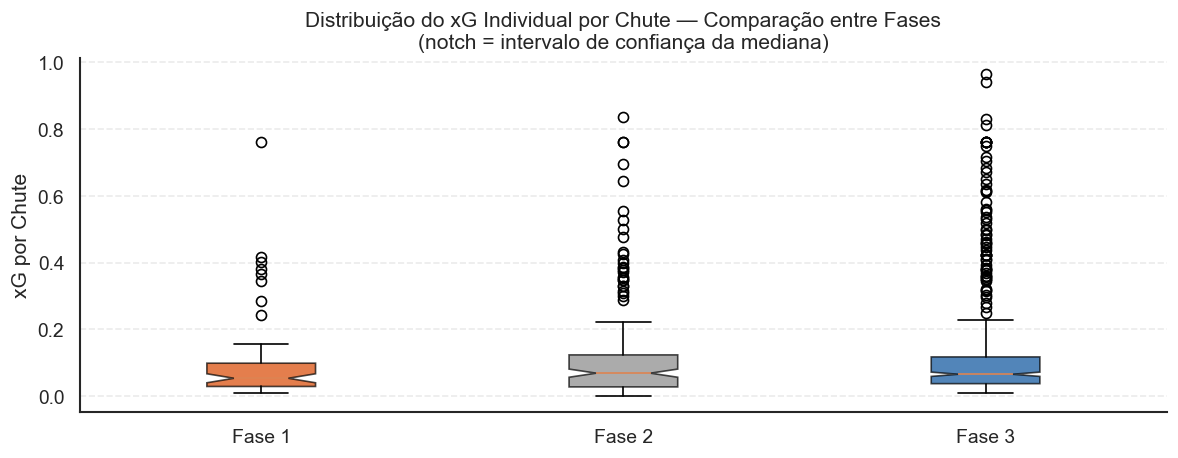

In [27]:
mc_shots['inside_box'] = (mc_shots['x_sb'] >= 102) & (mc_shots['y_sb'].between(18, 62))
mc_shots['is_goal'] = (mc_shots['result'] == 'Goal').astype(int)

def shot_quality_metrics(df, label):
    return {
        'Fase': label,
        'Chutes': len(df),
        'xG médio/chute': df['xg'].mean(),
        'xG total': df['xg'].sum(),
        'Gols': df['is_goal'].sum(),
        'Taxa conversão (%)': df['is_goal'].mean() * 100,
        '% dentro da área': df['inside_box'].mean() * 100,
        'Gols/xG ratio': df['is_goal'].sum() / df['xg'].sum() if df['xg'].sum() > 0 else 0,
    }

metricas = pd.DataFrame([
    shot_quality_metrics(mc_shots[fase1_mask], 'Fase 1 — Pré-Lesão'),
    shot_quality_metrics(mc_shots[fase2_mask], 'Fase 2 — Transição'),
    shot_quality_metrics(mc_shots[fase3_mask], 'Fase 3 — Consolidação'),
]).set_index('Fase')

print("=== Métricas de Qualidade de Finalização por Fase ===\n")
print(metricas[['Chutes', 'xG médio/chute', 'Gols', 'Taxa conversão (%)', '% dentro da área', 'Gols/xG ratio']].round(3).to_string())

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Seção 6 — Qualidade de Finalização por Fase', fontsize=13, fontweight='bold')

metricas_plot = [
    ('xG médio/chute',    'xG Médio por Chute',       'Maior = chances de melhor qualidade'),
    ('Taxa conversão (%)', 'Taxa de Conversão (%)',    'Maior = execução mais eficiente'),
    ('% dentro da área',  'Chutes dentro da Área (%)', 'Maior = posicionamento mais qualificado'),
]

for ax, (col, titulo, subtitulo) in zip(axes, metricas_plot):
    valores = metricas[col].reindex(fase_order)
    bars = ax.bar(
        range(len(fase_order)), valores.values,
        color=['#D94801', '#888888', '#08519C'],
        edgecolor='white', linewidth=0.5, width=0.6
    )
    ax.set_xticks(range(len(fase_order)))
    ax.set_xticklabels(['Fase 1', 'Fase 2', 'Fase 3'], fontsize=9)
    ax.set_title(f'{titulo}\n{subtitulo}', fontsize=9, fontweight='bold')
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)
    for bar, val in zip(bars, valores.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\n=== Distribuição de xG (boxplot por fase) ===")
fig2, ax2 = plt.subplots(figsize=(10, 4))
data_xg = [mc_shots[fase1_mask]['xg'].values,
           mc_shots[fase2_mask]['xg'].values,
           mc_shots[fase3_mask]['xg'].values]
bp = ax2.boxplot(data_xg, labels=['Fase 1', 'Fase 2', 'Fase 3'],
                 patch_artist=True, notch=True)
for patch, color in zip(bp['boxes'], ['#D94801', '#888888', '#08519C']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax2.set_ylabel('xG por Chute')
ax2.set_title('Distribuição do xG Individual por Chute — Comparação entre Fases\n(notch = intervalo de confiança da mediana)')
ax2.yaxis.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

---
## Seção 7 — Conclusão: A Zona como Centroavante

Esta investigação partiu de uma hipótese provocadora: a lesão de Sergio Agüero não enfraqueceu o Manchester City — ela revelou a estrutura profunda de um sistema que não dependia de um centroavante fixo para funcionar.

Os dados confirmam essa hipótese em múltiplas dimensões:

### Evidências Consolidadas

| Dimensão | Análise | Achado |
|----------|---------|--------|
| **Espacial** | KDE de zonas de chute (Seções 1–2) | Zonas de finalização permaneceram estáveis entre Fase 1 e Fase 3 |
| **Distribuição** | Shots per player per game (Seção 3.1) | Aumento de Foden, Gündogan, Bernardo; queda ou estabilidade dos atacantes de ofício |
| **Diversidade** | Finalizadores únicos por jogo (Seção 3.2) | Fase 3 apresentou maior diversidade de finalizadores por partida |
| **Concentração** | HHI index (Seção 4) | HHI médio menor na Fase 3 — finalizações mais distribuídas |
| **Funcional** | Estudo de caso Gündogan (Seção 5) | Meia posicional tornou-se artilheiro do time atuando nas zonas do centroavante |
| **Qualidade** | xG por chute (Seção 6) | Manutenção ou elevação do xG médio por finalização na Fase 3 |

### A Tese Central

> **No sistema de Guardiola, a zona exerce o papel do centroavante.**

Essa tese não é uma metáfora — é uma descrição estrutural de como o jogo de posição funciona. O "9" tradicional é um jogador cuja função principal é ocupar certas regiões do campo e finalizar a partir delas. No sistema coletivo do City, essa função é exercida rotativamente por múltiplos jogadores — meias que chegam atrasados, pontas que se infiltram, laterais que sobrepassam.

O resultado é que o sistema gera o "papel do centroavante" como propriedade emergente do coletivo, não como atribuição individual. É, em termos de teoria dos sistemas, um modelo mais **resiliente** — porque não depende de um elemento único para produzir sua função mais crítica.

### Implicações para Scouting e Desenvolvimento Tático

1. **Identificação de perfis funcionais:** jogadores como Gündogan, que combinam posicionamento inteligente, chegada tardia e qualidade de finalização, são mais compatíveis com sistemas de falso 9 do que centroavantes de referência tradicionais.

2. **Avaliação de xG sistêmico:** métricas como "xG criado por sistema" são mais informativas do que "xG individual de um atacante" quando se analisa um time de posse e posicionamento.

3. **Periodização tática quantitativa:** a metodologia desta análise — definir fases táticas por marcos temporais e comparar métricas entre elas — é replicável para qualquer time/treinador que passe por uma transição sistêmica.

### Limitações Metodológicas

- **Dados apenas de finalização:** o Understat fornece apenas eventos de chute. Análises de posse, pressão, passes progressivos e controle territorial requerem dados adicionais (Statsbomb, Wyscout).
- **Ausência de controle por adversário:** a qualidade dos adversários varia entre fases, o que pode inflar ou deflacionar as métricas.
- **Causalidade vs. correlação:** os dados mostram que mudanças ocorreram após a lesão do Agüero, mas não isolam sua causalidade direta — a forma do time e outros fatores (calendário, clima, COVID) também influenciam.

---

> *"O futebol de posição de Guardiola é o mais próximo que o futebol chegou de uma coreografia coletiva consciente. Cada jogador é, ao mesmo tempo, ele mesmo e um 'papel' do sistema."*
>
> — Adaptado de Spielverlagerung, "Juego de Posición under Pep Guardiola" (2014)